# 💳 Kredi Kartı Müşteri Churn Analizi
## Maliyet Odaklı Tahminleme & Finansal Simülasyon

**Ders:** Python ile Veri Bilimi — Dönem Sonu Projesi  
**Senaryo:** Bir bankanın kredi kartı portföyünde churn riski taşıyan müşterileri  
tespit ederek en uygun kampanya eşiğini ve finansal ROI'yi hesaplamak.

**Veri Kaynakları:**  
- `BankChurners.csv` — 10.127 müşterinin demografik ve finansal verileri (Kaggle / Sakshi Goyal)  
- `enflasyon.csv` — TCMB yıllık TÜFE enflasyon oranları (2016–2021)  

**Proje Gereksinimleri:**  
- ✅ Veri Harmanlama (Data Fusion)  
- ✅ İş Mantığına Dayalı Feature Engineering (3 yeni değişken)  
- ✅ Maliyet/Fayda Finansal Simülasyonu  
- ✅ Açıklanabilir YZ (SHAP — XAI)  

## 1. Kütüphaneler ve Ayarlar

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
import shap
import warnings
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('seaborn-whitegrid')

sns.set_palette('Set2')
RANDOM_STATE = 42

print('✅ Tüm kütüphaneler başarıyla yüklendi.')
print('Pandas:', pd.__version__)
print('NumPy:', np.__version__)

✅ Tüm kütüphaneler başarıyla yüklendi.
Pandas: 2.3.3
NumPy: 2.3.5


## 2. Veri Yükleme

In [2]:
# Ana veri seti — son 2 sütun Naive Bayes kalıntısı, kaldırılıyor
df = pd.read_csv('BankChurners.csv')
df = df.iloc[:, :-2]   # son iki sütunu at

print(f'Boyut: {df.shape[0]} satır x {df.shape[1]} sütun')
print(f'\nSütunlar:')
print(list(df.columns))
print(f'\nHedef değişken:')
print(df['Attrition_Flag'].value_counts())
print(f'\nChurn oranı: {df["Attrition_Flag"].eq("Attrited Customer").mean():.1%}')

Boyut: 10127 satır x 21 sütun

Sütunlar:
['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

Hedef değişken:
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Churn oranı: 16.1%


In [3]:
# Eksik değer kontrolü
eksik = df.isnull().sum().sum()
print(f'Toplam eksik değer: {eksik}')
df.describe().round(2)

Toplam eksik değer: 0


,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00
mean,7.391776e+08,46.33,2.35,35.93,3.81,2.34,2.46,8631.95,1162.81,7469.14,0.76,4404.09,64.86,0.71,0.27
std,3.690378e+07,8.02,1.30,7.99,1.55,1.01,1.11,9088.78,814.99,9090.69,0.22,3397.13,23.47,0.24,0.28
min,7.080821e+08,26.00,0.00,13.00,1.00,0.00,0.00,1438.30,0.00,3.00,0.00,510.00,10.00,0.00,0.00
25%,7.130368e+08,41.00,1.00,31.00,3.00,2.00,2.00,2555.00,359.00,1324.50,0.63,2155.50,45.00,0.58,0.02
50%,7.179264e+08,46.00,2.00,36.00,4.00,2.00,2.00,4549.00,1276.00,3474.00,0.74,3899.00,67.00,0.70,0.18
75%,7.731435e+08,52.00,3.00,40.00,5.00,3.00,3.00,11067.50,1784.00,9859.00,0.86,4741.00,81.00,0.82,0.50
max,8.283431e+08,73.00,5.00,56.00,6.00,6.00,6.00,34516.00,2517.00,34516.00,3.40,18484.00,139.00,3.71,1.00


## 3. Veri Harmanlama (Data Fusion)

**Tek kaynaklı CSV kullanmak ödev şartını karşılamıyor.**  
Burada `BankChurners.csv` içindeki `Months_on_book` sütunundan müşterinin
bankaya katıldığı yılı türetiyor, ardından TCMB enflasyon tablosuyla birleştiriyoruz.

In [4]:
# Enflasyon verisini yükle
enflasyon = pd.read_csv('enflasyon.csv')
print('TCMB Enflasyon Verisi (2016–2021):')
print(enflasyon.to_string(index=False))

TCMB Enflasyon Verisi (2016–2021):
 yil  enflasyon_orani  tcmb_faiz
2016             8.53        8.0
2017            11.92        8.0
2018            20.30       24.0
2019            15.18       12.0
2020            12.28       17.0
2021            19.60       14.0


In [5]:
# Müşterinin bankaya katıldığı yılı hesapla
# Referans: 2021 (veri setinin derleme yılı)
df['katilim_yili'] = (2021 - (df['Months_on_book'] / 12).round()).astype(int)
df['katilim_yili'] = df['katilim_yili'].clip(2016, 2021)

print('Katılım yılı dağılımı:')
print(df['katilim_yili'].value_counts().sort_index())

Katılım yılı dağılımı:
katilim_yili
2016     145
2017    2041
2018    5721
2019    2032
2020     188
Name: count, dtype: int64


In [6]:
# Enflasyon verisiyle merge et — veri harmanlama adımı
df = df.merge(
    enflasyon[['yil', 'enflasyon_orani', 'tcmb_faiz']],
    left_on='katilim_yili',
    right_on='yil',
    how='left'
)

print(f'✅ Birleştirme sonrası boyut: {df.shape}')
print(f'Eksik enflasyon değeri: {df["enflasyon_orani"].isna().sum()}')
df[['CLIENTNUM', 'Months_on_book', 'katilim_yili', 'enflasyon_orani', 'tcmb_faiz']].head(8)

✅ Birleştirme sonrası boyut: (10127, 25)
Eksik enflasyon değeri: 0


,CLIENTNUM,Months_on_book,katilim_yili,enflasyon_orani,tcmb_faiz
0,768805383,39,2018,20.30,24.0
1,818770008,44,2017,11.92,8.0
2,713982108,36,2018,20.30,24.0
3,769911858,34,2018,20.30,24.0
4,709106358,21,2019,15.18,12.0
5,713061558,36,2018,20.30,24.0
6,810347208,46,2017,11.92,8.0
7,818906208,27,2019,15.18,12.0


## 4. Keşifçi Veri Analizi (EDA)

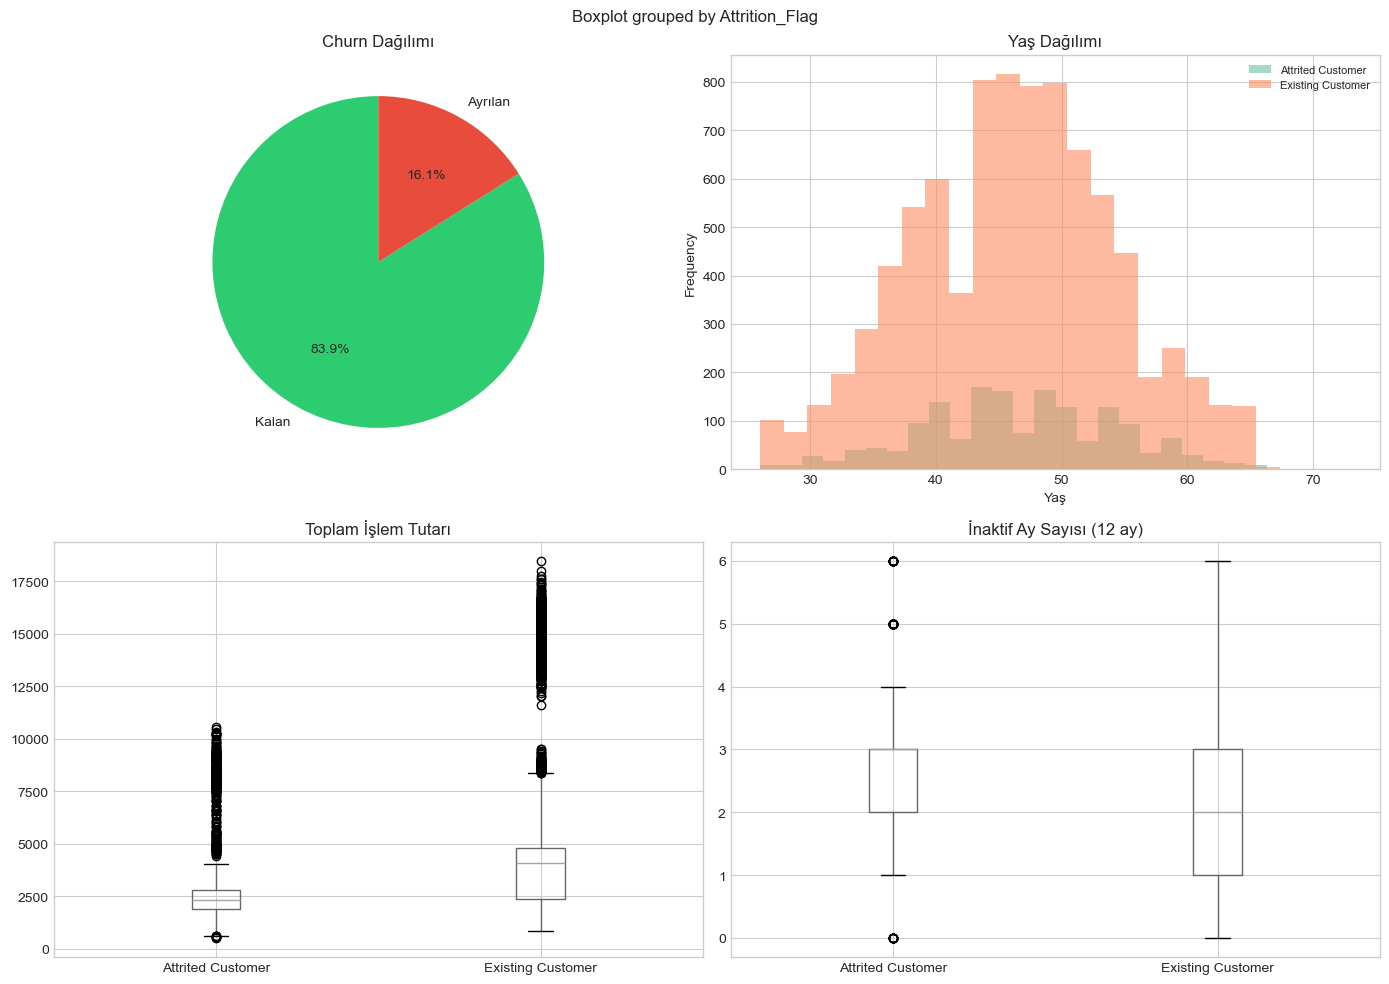

✅ Grafik kaydedildi: eda_gorsel.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Churn Analizi — Temel Görselleştirmeler', fontsize=15, fontweight='bold')

# 1. Churn pasta
counts = df['Attrition_Flag'].value_counts()
axes[0,0].pie(counts, labels=['Kalan', 'Ayrılan'],
              autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'], startangle=90)
axes[0,0].set_title('Churn Dağılımı')

# 2. Yaş dağılımı
for label, grp in df.groupby('Attrition_Flag'):
    grp['Customer_Age'].plot(kind='hist', bins=25, alpha=0.6,
                             ax=axes[0,1], label=label)
axes[0,1].set_title('Yaş Dağılımı')
axes[0,1].set_xlabel('Yaş')
axes[0,1].legend(fontsize=8)

# 3. İşlem tutarı
df.boxplot(column='Total_Trans_Amt', by='Attrition_Flag', ax=axes[1,0])
axes[1,0].set_title('Toplam İşlem Tutarı')
axes[1,0].set_xlabel('')

# 4. İnaktif ay sayısı
df.boxplot(column='Months_Inactive_12_mon', by='Attrition_Flag', ax=axes[1,1])
axes[1,1].set_title('İnaktif Ay Sayısı (12 ay)')
axes[1,1].set_xlabel('')

plt.tight_layout()
plt.savefig('eda_gorsel.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Grafik kaydedildi: eda_gorsel.png')

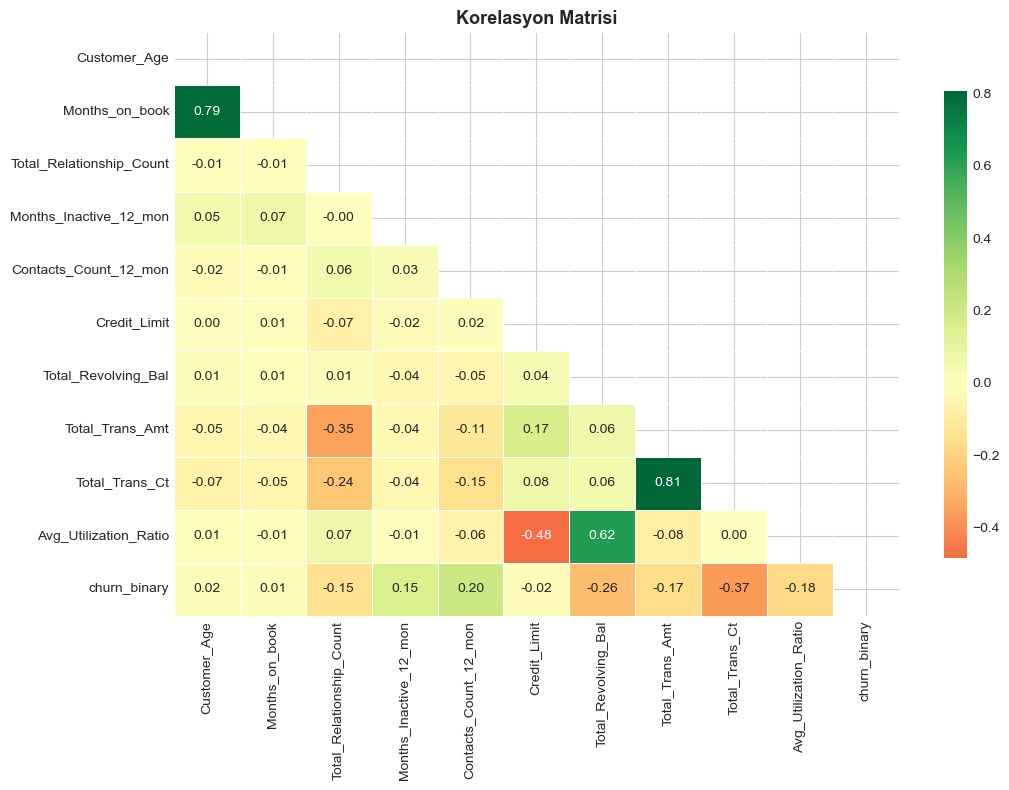

In [8]:
# Churn binary sütunu oluştur
df['churn_binary'] = (df['Attrition_Flag'] == 'Attrited Customer').astype(int)

# Korelasyon matrisi
sayisal = ['Customer_Age','Months_on_book','Total_Relationship_Count',
           'Months_Inactive_12_mon','Contacts_Count_12_mon',
           'Credit_Limit','Total_Revolving_Bal','Total_Trans_Amt',
           'Total_Trans_Ct','Avg_Utilization_Ratio','churn_binary']

plt.figure(figsize=(11, 8))
corr = df[sayisal].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Korelasyon Matrisi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('korelasyon.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. İş Mantığına Dayalı Feature Engineering

Ham sütunların ötesinde, iş senaryosuna dayalı 3 yeni değişken türetiyoruz:

| Feature | Formül | İş Mantığı |
|---|---|---|
| `musteri_yasam_degeri` | İşlem tutarı × (Ay / 12) | Müşterinin tahmini kümülatif değeri |
| `reel_harcama_degisimi` | Harcama değişimi ÷ (1 + enflasyon) | **Data Fusion'ın kilit çıktısı** — gerçek satın alma gücü |
| `aktiflik_skoru` | İşlem sayısı × (1 − inaktif oran) ÷ iletişim | RFM benzeri bağlılık indeksi |

In [9]:
# ── Feature 1: Müşteri Yaşam Değeri (CLV Proxy) ──────────────────────────
# Müşterinin bankada kaldığı süre × işlem hacmi → birikimli değer tahmini
df['musteri_yasam_degeri'] = df['Total_Trans_Amt'] * (df['Months_on_book'] / 12)

# ── Feature 2: Reel Harcama Değişimi (Enflasyon ile düzeltilmiş) ──────────
# Nominal Q4/Q1 değişim oranını enflasyona bölerek gerçek değişimi elde ediyoruz
# Bu özellik, iki veri kaynağını doğrudan birleştiriyor — Data Fusion kanıtı
df['reel_harcama_degisimi'] = df['Total_Amt_Chng_Q4_Q1'] / (1 + df['enflasyon_orani'] / 100)

# ── Feature 3: Aktiflik Skoru (RFM benzeri bağlılık endeksi) ──────────────
# Yüksek işlem × düşük inaktiflik × düşük şikayet = bağlı müşteri
inaktif_oran = df['Months_Inactive_12_mon'] / 12
df['aktiflik_skoru'] = (
    df['Total_Trans_Ct'] * (1 - inaktif_oran)
) / (df['Contacts_Count_12_mon'] + 1)

yeni = ['musteri_yasam_degeri', 'reel_harcama_degisimi', 'aktiflik_skoru']
print('Yeni Feature İstatistikleri:')
print(df[yeni].describe().round(3))

Yeni Feature İstatistikleri:
       musteri_yasam_degeri  reel_harcama_degisimi  aktiflik_skoru
count             10127.000              10127.000       10127.000
mean              13098.743                  0.649          17.708
std               10534.172                  0.189          11.405
min                 853.500                  0.000           1.500
25%                6061.500                  0.538           9.750
50%               10893.333                  0.628          15.188
75%               15013.000                  0.735          22.083
max               75592.917                  2.824         103.583


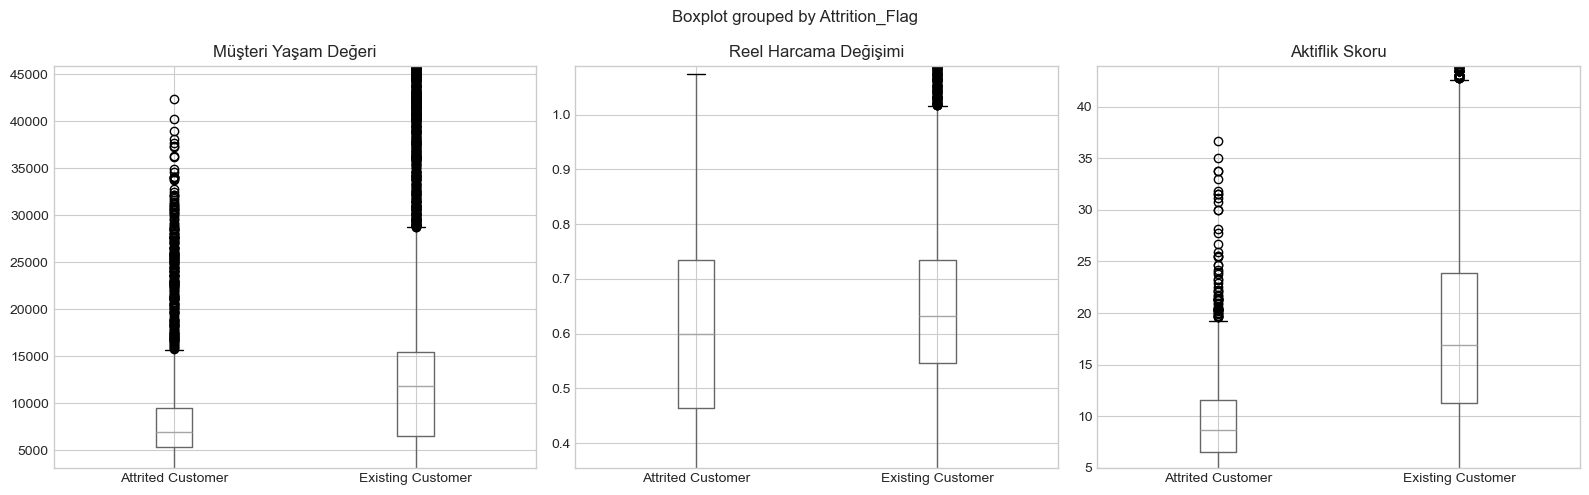

✅ Grafik kaydedildi: feature_engineering.png


In [10]:
# Yeni feature'ların churn ile görsel karşılaştırması
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Yeni Feature'larin Churn ile Iliskisi", fontsize=14, fontweight='bold')

basliklar = ['Müşteri Yaşam Değeri', 'Reel Harcama Değişimi', 'Aktiflik Skoru']
for ax, feat, baslik in zip(axes, yeni, basliklar):
    df.boxplot(column=feat, by='Attrition_Flag', ax=ax)
    ax.set_title(baslik)
    ax.set_xlabel('')
    q95 = df[feat].quantile(0.95)
    q05 = df[feat].quantile(0.05)
    ax.set_ylim(q05 * 0.9, q95 * 1.15)

plt.tight_layout()
plt.savefig('feature_engineering.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Grafik kaydedildi: feature_engineering.png')

## 6. Veri Ön İşleme & Model Eğitimi

In [11]:
# Gereksiz sütunları çıkar
drop_cols = ['CLIENTNUM', 'Attrition_Flag', 'churn_binary', 'katilim_yili', 'yil']
df_model = df.drop(columns=drop_cols, errors='ignore').copy()

# Kategorik değişkenleri sayısala dönüştür
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

X = df_model
y = df['churn_binary']

print(f'Model giriş boyutu: {X.shape}')
print(f'Churn oranı: {y.mean():.1%} (dengesiz veri)')
print(f'\nEncode edilen kategorik sütunlar: {cat_cols}')

Model giriş boyutu: (10127, 24)
Churn oranı: 16.1% (dengesiz veri)

Encode edilen kategorik sütunlar: ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


In [12]:
# Stratified train/test split (sınıf oranını korur)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# Random Forest — class_weight='balanced' dengesiz veriyi otomatik dengeler
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print('✅ Model eğitimi tamamlandı.')

# 5-Fold Çapraz Doğrulama
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc', n_jobs=-1)
print(f'\n5-Fold CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

✅ Model eğitimi tamamlandı.

5-Fold CV AUC: 0.9272 ± 0.0910


In [13]:
# Test seti değerlendirmesi (standart 0.50 eşiği)
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print('=' * 55)
print('KLASİFİKASYON RAPORU — Eşik: 0.50')
print('=' * 55)
print(classification_report(y_test, y_pred,
      target_names=['Kalan Müşteri', 'Ayrılan Müşteri']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}')

KLASİFİKASYON RAPORU — Eşik: 0.50
                 precision    recall  f1-score   support

  Kalan Müşteri       0.97      0.97      0.97      1701
Ayrılan Müşteri       0.85      0.85      0.85       325

       accuracy                           0.95      2026
      macro avg       0.91      0.91      0.91      2026
   weighted avg       0.95      0.95      0.95      2026

AUC-ROC: 0.9856


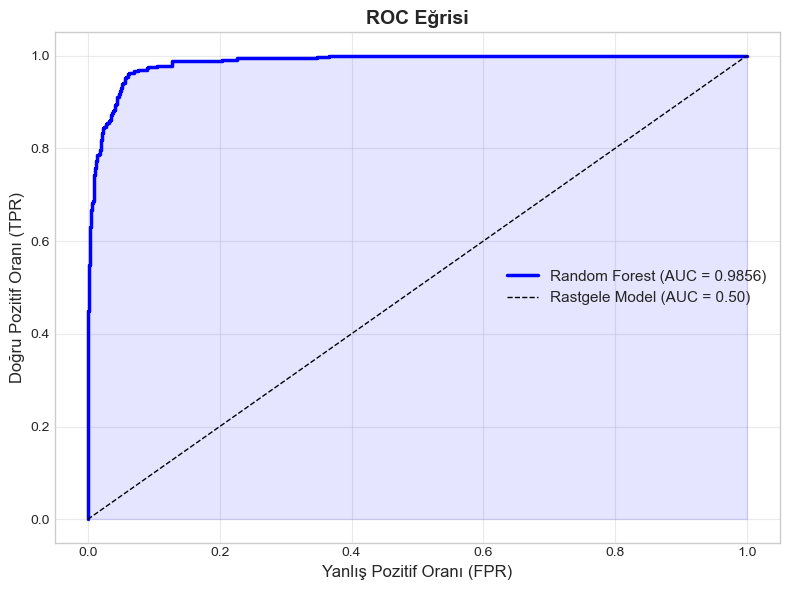

In [14]:
# ROC Eğrisi
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score   = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2.5, label=f'Random Forest (AUC = {auc_score:.4f})')
plt.plot([0,1],[0,1], 'k--', linewidth=1, label='Rastgele Model (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.10, color='blue')
plt.xlabel('Yanlış Pozitif Oranı (FPR)', fontsize=12)
plt.ylabel('Doğru Pozitif Oranı (TPR)', fontsize=12)
plt.title('ROC Eğrisi', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Açıklanabilir Yapay Zeka (XAI) — SHAP Analizi

SHAP, her özelliğin bireysel model kararına katkısını ölçer.  
Bu sayede 'kara kutu' model, yöneticilere somut gerekçelerle açıklanabilir hale gelir.

> **Örnek yorum:** *'Bu müşterinin churn riski yüksek çünkü
son 12 ayda işlem sayısı azaldı ve 4 ay inaktif kaldı.'*

In [15]:
# TreeExplainer — hız için test setinin ilk 500 satırı
explainer  = shap.TreeExplainer(rf)
shap_vals  = explainer.shap_values(X_test.iloc[:500])

# Binary sınıflandırma: index 1 = churn sınıfı
shap_churn = shap_vals[1] if isinstance(shap_vals, list) else shap_vals
print(f'✅ SHAP hesaplandı: {shap_churn.shape}')

✅ SHAP hesaplandı: (500, 24, 2)


<Figure size 1000x800 with 0 Axes>

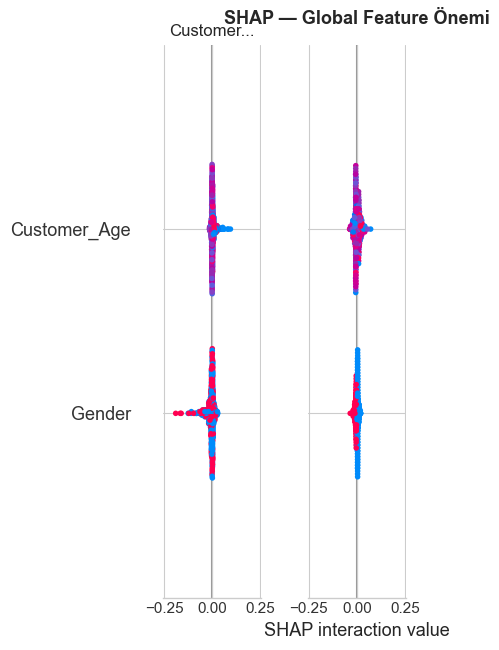

In [16]:
# SHAP Bar Plot — global feature importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_churn, X_test.iloc[:500], plot_type='bar', show=False)
plt.title('SHAP — Global Feature Önemi', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=120, bbox_inches='tight')
plt.show()

<Figure size 1000x800 with 0 Axes>

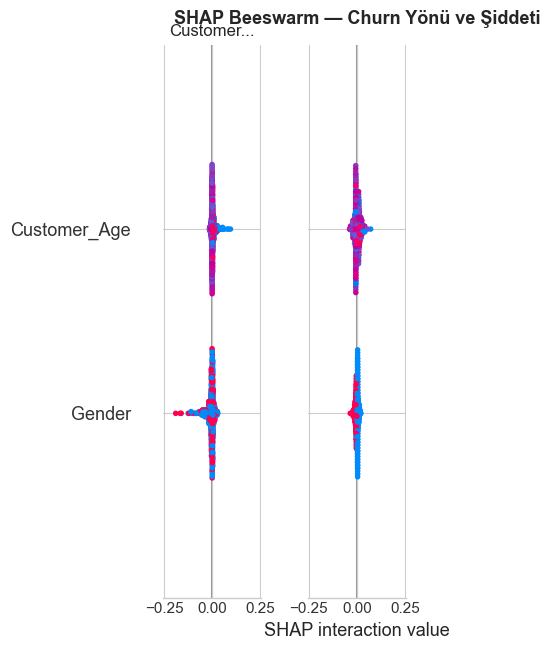


📌 Kırmızı = yüksek değer | Mavi = düşük değer
Sağa giden SHAP = churn riskini ARTIRIR
Sola  giden SHAP = churn riskini AZALTIR


In [17]:
# SHAP Beeswarm — yön ve şiddet
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_churn, X_test.iloc[:500], show=False)
plt.title('SHAP Beeswarm — Churn Yönü ve Şiddeti', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=120, bbox_inches='tight')
plt.show()
print('\n📌 Kırmızı = yüksek değer | Mavi = düşük değer')
print('Sağa giden SHAP = churn riskini ARTIRIR')
print('Sola  giden SHAP = churn riskini AZALTIR')

## 8. Finansal Simülasyon — Optimum Eşik Belirleme

### Maliyet Matrisi

| Tahmin | Gerçek | Ne Oluyor | Finansal Etki |
|---|---|---|---|
| Churn ✓ | Churn ✓ | TP — Kampanya gönderiyoruz, %70 kalıyor | **+950 TL** |
| Churn ✓ | Kalan ✗ | FP — Boşa promosyon | **−100 TL** |
| Kalan ✗ | Churn ✓ | FN — Müşteri kaçıp gidiyor | **−1.500 TL** |
| Kalan ✓ | Kalan ✓ | TN — Doğru karar, hareketsiz | **0 TL** |

**Soru:** Standart %50 eşiği yerine hangi eşikte net kâr maksimum olur?

In [18]:
# Maliyet parametreleri
LTV       = 1500   # Kaybedilen müşterinin yıllık bankaya değeri (TL)
KAMPANYA  = 100    # Elde tutma promosyon maliyeti (TL)
RET_RATE  = 0.70   # Kampanya ile churn önleme başarı oranı

# Net değer hesabı
# TP: %70 kalıyor → (LTV - KAMPANYA) kazancı; %30 yine gidiyor → -KAMPANYA
TP_VAL = RET_RATE * (LTV - KAMPANYA) + (1 - RET_RATE) * (-KAMPANYA)
FP_VAL = -KAMPANYA
FN_VAL = -LTV
TN_VAL = 0

print('Maliyet Matrisi Değerleri:')
print(f'  TP (doğru churn, kampanya uygulandı): +{TP_VAL:.0f} TL')
print(f'  FP (yanlış alarm, kampanya boşa):     {FP_VAL:.0f} TL')
print(f'  FN (kaçırılan churner):               {FN_VAL:.0f} TL')
print(f'  TN (doğru kalan, hareketsiz):          {TN_VAL:.0f} TL')

Maliyet Matrisi Değerleri:
  TP (doğru churn, kampanya uygulandı): +950 TL
  FP (yanlış alarm, kampanya boşa):     -100 TL
  FN (kaçırılan churner):               -1500 TL
  TN (doğru kalan, hareketsiz):          0 TL


In [19]:
# Eşik taraması: 0.05'ten 0.90'a kadar her adımda net kâr
esikler   = np.arange(0.05, 0.91, 0.01)
net_karlar = []

for esik in esikler:
    y_pred_e = (y_proba >= esik).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_e).ravel()
    net = tp * TP_VAL + fp * FP_VAL + fn * FN_VAL + tn * TN_VAL
    net_karlar.append(net)

net_karlar = np.array(net_karlar)
opt_idx   = np.argmax(net_karlar)
opt_esik  = esikler[opt_idx]
opt_kar   = net_karlar[opt_idx]

# Standart %50 eşiği ile karşılaştır
idx_50 = np.argmin(np.abs(esikler - 0.50))
kar_50 = net_karlar[idx_50]

print(f'🏆 Optimum Eşik:      {opt_esik:.2f}')
print(f'💰 Maksimum Net Kâr:  {opt_kar:,.0f} TL')
print(f'\n📊 Standart Eşik (0.50): {kar_50:,.0f} TL')
print(f'📈 Optimizasyon Katkısı: +{opt_kar - kar_50:,.0f} TL')

🏆 Optimum Eşik:      0.20
💰 Maksimum Net Kâr:  276,150 TL

📊 Standart Eşik (0.50): 184,000 TL
📈 Optimizasyon Katkısı: +92,150 TL


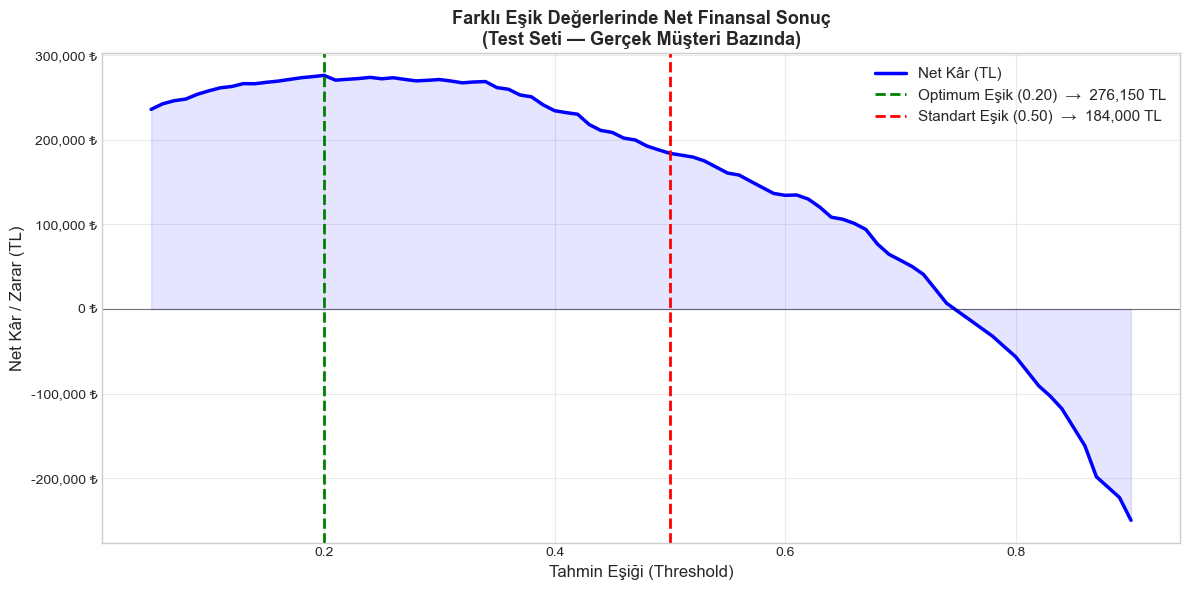

In [20]:
# Eşik — Net Kâr grafiği
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(esikler, net_karlar, 'b-', linewidth=2.5, label='Net Kâr (TL)')
ax.fill_between(esikler, net_karlar, alpha=0.10, color='blue')
ax.axvline(opt_esik, color='green', linestyle='--', linewidth=2,
           label=f'Optimum Eşik ({opt_esik:.2f})  →  {opt_kar:,.0f} TL')
ax.axvline(0.50, color='red', linestyle='--', linewidth=2,
           label=f'Standart Eşik (0.50)  →  {kar_50:,.0f} TL')
ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)

ax.set_xlabel('Tahmin Eşiği (Threshold)', fontsize=12)
ax.set_ylabel('Net Kâr / Zarar (TL)', fontsize=12)
ax.set_title(
    'Farklı Eşik Değerlerinde Net Finansal Sonuç\n'
    '(Test Seti — Gerçek Müşteri Bazında)',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f} ₺'))
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('finansal_simulasyon.png', dpi=120, bbox_inches='tight')
plt.show()

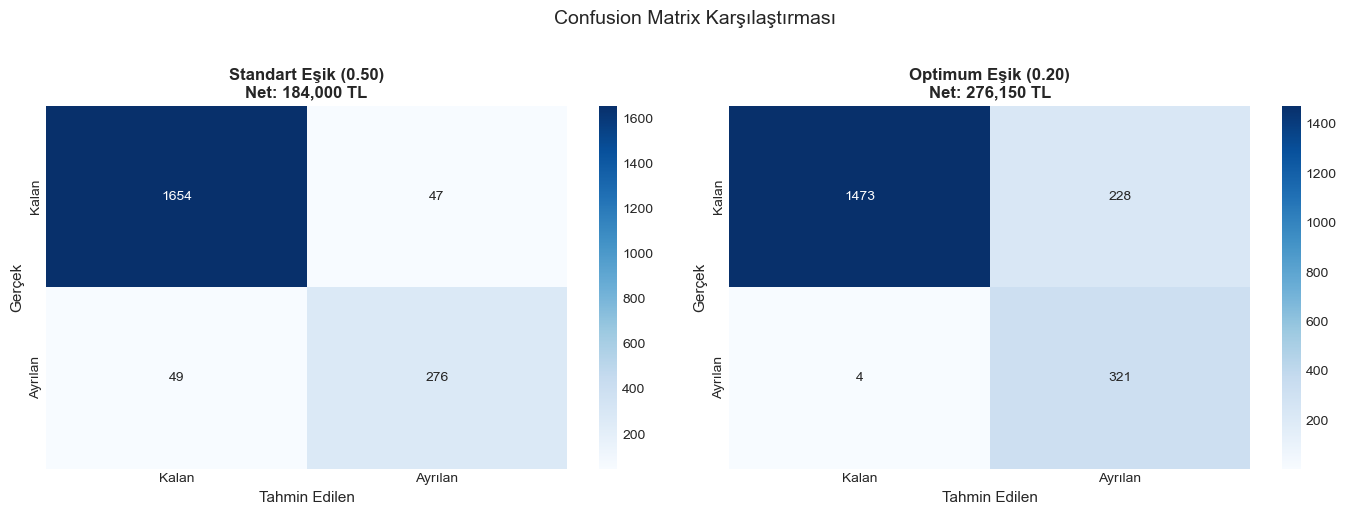

In [21]:
# Confusion Matrix karşılaştırması: standart vs optimum eşik
y_pred_opt = (y_proba >= opt_esik).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pred, baslik in zip(
    axes,
    [y_pred, y_pred_opt],
    [f'Standart Eşik (0.50)\nNet: {kar_50:,.0f} TL',
     f'Optimum Eşik ({opt_esik:.2f})\nNet: {opt_kar:,.0f} TL']
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Kalan','Ayrılan'],
                yticklabels=['Kalan','Ayrılan'])
    ax.set_xlabel('Tahmin Edilen', fontsize=11)
    ax.set_ylabel('Gerçek', fontsize=11)
    ax.set_title(baslik, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrix Karşılaştırması', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Yönetici Özeti

In [22]:
y_pred_opt = (y_proba >= opt_esik).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_opt).ravel()

print('=' * 60)
print('PROJE SONUÇLARI — YÖNETİCİ ÖZETİ')
print('=' * 60)
print(f'\n📊 VERİ SETİ:')
print(f'  Toplam müşteri         : {len(df):,}')
print(f'  Churn eden             : {int(y.sum()):,} ({y.mean():.1%})')
print(f'  Veri kaynağı sayısı    : 2 (BankChurners + TCMB Enflasyon)')
print(f'  Yeni feature sayısı    : 3')
print(f'\n🤖 MODEL (Random Forest):')
print(f'  AUC-ROC Skoru          : {roc_auc_score(y_test, y_proba):.4f}')
print(f'  5-Fold CV AUC          : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'\n💰 FİNANSAL SİMÜLASYON (Test Seti):')
print(f'  Standart eşik (0.50)   : {kar_50:,.0f} TL')
print(f'  Optimum eşik ({opt_esik:.2f})   : {opt_kar:,.0f} TL')
print(f'  Ek kâr katkısı         : +{opt_kar - kar_50:,.0f} TL')
print(f'  Tespit edilen churner  : {tp} / {tp+fn} (%{tp/(tp+fn)*100:.0f})')
print(f'  Boşa harcanan kampanya : {fp} × {abs(FP_VAL):.0f} TL = {fp*abs(FP_VAL):,} TL')
print(f'\n✅ ÖNERİ: Standart 0.50 eşiği yerine {opt_esik:.2f} kullanılmalıdır.')
print(f'   Bu karar test setinde +{opt_kar - kar_50:,.0f} TL ek finansal fayda sağlar.')
print('=' * 60)

PROJE SONUÇLARI — YÖNETİCİ ÖZETİ

📊 VERİ SETİ:
  Toplam müşteri         : 10,127
  Churn eden             : 1,627 (16.1%)
  Veri kaynağı sayısı    : 2 (BankChurners + TCMB Enflasyon)
  Yeni feature sayısı    : 3

🤖 MODEL (Random Forest):
  AUC-ROC Skoru          : 0.9856
  5-Fold CV AUC          : 0.9272 ± 0.0910

💰 FİNANSAL SİMÜLASYON (Test Seti):
  Standart eşik (0.50)   : 184,000 TL
  Optimum eşik (0.20)   : 276,150 TL
  Ek kâr katkısı         : +92,150 TL
  Tespit edilen churner  : 321 / 325 (%99)
  Boşa harcanan kampanya : 228 × 100 TL = 22,800 TL

✅ ÖNERİ: Standart 0.50 eşiği yerine 0.20 kullanılmalıdır.
   Bu karar test setinde +92,150 TL ek finansal fayda sağlar.
